# Notebook 01 — Acquisition & Exploration des Données (3 classes)
**Projet :** Système Intelligent de Détection de Spam et de Phishing  
**Auteur :** Nghogué Taptué Franck Roddier — 5GI, ENSPY  
**Semaine :** 1 / 3  

---

## Sources utilisées

| Classe | Dataset | Accès | Volume estimé |
|--------|---------|-------|---------------|
| **Ham** | Enron Ham (Kaggle) | CSV direct | ~17 000 emails |
| **Spam** | Enron Spam (Kaggle) | CSV direct | ~17 000 emails |
| **Phishing** | Nazario Phishing Corpus | GitHub clone | ~2 400 emails |

## Prérequis avant d'exécuter ce notebook

### 1. Dataset Enron (ham + spam)
1. Créer un compte sur [kaggle.com](https://www.kaggle.com) (gratuit)
2. Aller sur : `https://www.kaggle.com/datasets/wcukierski/enron-email-dataset`
3. Télécharger `emails.csv` et le placer dans `data/enron_emails.csv`
4. **Alternative plus légère** : `https://www.kaggle.com/datasets/veleon/ham-and-spam-dataset` → fichiers `ham.csv` et `spam.csv`

### 2. Corpus Phishing Nazario
```bash
# Dans un terminal, dans le dossier du projet :
git clone https://github.com/nazario/phishing-corpus data/phishing-corpus
```
Si git n'est pas disponible : télécharger le ZIP depuis GitHub → extraire dans `data/phishing-corpus/`

> **Si vous ne pouvez pas télécharger ces données**, le notebook génère automatiquement un dataset synthétique de démonstration. Il est suffisant pour comprendre la démarche, mais insuffisant pour un système réel.

## 0. Installation des dépendances

In [19]:
# Exécuter une seule fois, puis commenter
!pip install pandas numpy matplotlib seaborn scikit-learn tqdm wordcloud

In [20]:
import os
from pathlib import Path
from google.colab import drive

# 1. Monter le drive
drive.mount('/content/drive')

# 2. Se déplacer dans le dossier du projet
# Remplace par le chemin exact de ton dossier
os.chdir('/content/drive/MyDrive/notebooks')

# 3. Vérifier que le dossier 'data' est bien là
DATA_DIR = Path('data')
if DATA_DIR.exists():
    print("Dossier data trouvé !")
else:
    print("Dossier data introuvable. Contenu actuel :", os.listdir())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dossier data trouvé !


In [21]:
import os
import re
import email
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from wordcloud import WordCloud

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

# Couleurs fixes pour les 3 classes — utilisées partout
CLASS_COLORS = {'ham': '#1D9E75', 'spam': '#D85A30', 'phishing': '#BA7517'}

print('Environnement prêt.')

Environnement prêt.


## 1. Chargement des données

### 1.1 — Enron Ham & Spam (Kaggle)

In [22]:
def load_enron_kaggle(csv_path: str) -> pd.DataFrame:
    """
    Charge le dataset Enron depuis un CSV Kaggle.

    Format attendu (ham-and-spam-dataset) :
      Colonnes : 'text', 'spam' (0=ham, 1=spam)

    Format alternatif (enron-email-dataset) :
      Colonnes : 'message', 'file'
      Dans ce cas, on parse le champ 'file' pour détecter les dossiers spam/ham.
    """
    df = pd.read_csv(csv_path)
    print(f'Colonnes trouvées : {list(df.columns)}')
    print(f'Lignes : {len(df)}')

    records = []

    # Format 1 : colonnes 'text' et 'spam'
    if 'text' in df.columns and 'spam' in df.columns:
        for _, row in df.iterrows():
            label = 'spam' if row['spam'] == 1 else 'ham'
            records.append({'text': str(row['text']), 'label': label, 'source': 'enron_kaggle'})

    # Format 2 : colonnes 'message' et 'file' (Enron complet)
    elif 'message' in df.columns and 'file' in df.columns:
        for _, row in df.iterrows():
            file_path = str(row.get('file', ''))
            # Les dossiers 'spam' dans le chemin indiquent un spam
            if 'spam' in file_path.lower():
                label = 'spam'
            else:
                label = 'ham'
            records.append({'text': str(row['message']), 'label': label, 'source': 'enron_kaggle'})

    else:
        print('Format non reconnu. Colonnes disponibles :', list(df.columns))
        return pd.DataFrame()

    return pd.DataFrame(records)


# Tentative de chargement
enron_paths = [
    DATA_DIR / 'enron_emails.csv',
    DATA_DIR / 'ham_spam.csv',
    DATA_DIR / 'emails.csv',
]

df_enron = pd.DataFrame()
for path in enron_paths:
    if path.exists():
        print(f'Chargement de {path}...')
        df_enron = load_enron_kaggle(str(path))
        if len(df_enron) > 0:
            break

if len(df_enron) == 0:
    print('Aucun fichier Enron trouvé dans data/.')
    print('Voir les instructions en haut du notebook pour télécharger le dataset.')
else:
    print(f'\nDataset Enron chargé : {len(df_enron)} emails')
    print(df_enron['label'].value_counts())

Aucun fichier Enron trouvé dans data/.
Voir les instructions en haut du notebook pour télécharger le dataset.


### 1.2 — Nazario Phishing Corpus (GitHub)

In [23]:
def parse_eml_file(filepath: str) -> str:
    """
    Parse un fichier .eml et retourne son contenu textuel.
    Extrait le sujet, l'expéditeur et le corps du message.
    """
    try:
        with open(filepath, 'rb') as f:
            msg = email.message_from_bytes(f.read())

        parts = []

        # En-têtes importants
        subject = msg.get('Subject', '')
        sender  = msg.get('From', '')
        if subject:
            parts.append(f'Subject: {subject}')
        if sender:
            parts.append(f'From: {sender}')

        # Corps du message
        if msg.is_multipart():
            for part in msg.walk():
                content_type = part.get_content_type()
                if content_type in ('text/plain', 'text/html'):
                    try:
                        charset = part.get_content_charset() or 'utf-8'
                        body = part.get_payload(decode=True).decode(charset, errors='replace')
                        parts.append(body)
                    except Exception:
                        pass
        else:
            try:
                charset = msg.get_content_charset() or 'utf-8'
                body = msg.get_payload(decode=True).decode(charset, errors='replace')
                parts.append(body)
            except Exception:
                parts.append(str(msg.get_payload()))

        return '\n'.join(parts)

    except Exception as e:
        return ''


def load_nazario_corpus(corpus_dir: Path) -> pd.DataFrame:
    """
    Charge tous les fichiers .eml du corpus Nazario.
    Structure attendue : data/phishing-corpus/**/*.eml
    """
    # Cherche tous les .eml dans le dossier et ses sous-dossiers
    eml_files = list(corpus_dir.rglob('*.eml'))

    # Certains corpus utilisent aussi .txt
    txt_files = list(corpus_dir.rglob('*.txt'))

    print(f'Fichiers .eml trouvés : {len(eml_files)}')
    print(f'Fichiers .txt trouvés : {len(txt_files)}')

    records = []

    for filepath in tqdm(eml_files, desc='Parsing .eml (phishing)'):
        text = parse_eml_file(str(filepath))
        if len(text.strip()) > 20:
            records.append({'text': text, 'label': 'phishing', 'source': 'nazario'})

    for filepath in tqdm(txt_files, desc='Parsing .txt (phishing)'):
        try:
            text = filepath.read_text(encoding='utf-8', errors='replace')
            if len(text.strip()) > 20:
                records.append({'text': text, 'label': 'phishing', 'source': 'nazario'})
        except Exception:
            pass

    return pd.DataFrame(records)


# Chemins possibles pour le corpus Nazario
nazario_paths = [
    DATA_DIR / 'phishing-corpus',
    DATA_DIR / 'phishing_corpus',
    DATA_DIR / 'nazario',
]

df_phishing = pd.DataFrame()
for path in nazario_paths:
    if path.exists():
        print(f'Corpus Nazario trouvé dans : {path}')
        df_phishing = load_nazario_corpus(path)
        break

if len(df_phishing) == 0:
    print('Corpus Nazario non trouvé.')
    print('Commande pour le télécharger :')
    print('  git clone https://github.com/nazario/phishing-corpus data/phishing-corpus')
else:
    print(f'\nCorpus phishing chargé : {len(df_phishing)} emails')

Corpus Nazario non trouvé.
Commande pour le télécharger :
  git clone https://github.com/nazario/phishing-corpus data/phishing-corpus


### 1.3 — Dataset synthétique de secours

Si les données réelles ne sont pas disponibles, ce dataset de démonstration permet de valider la pipeline.

In [24]:
# Dataset synthétique — utilisé uniquement si les données réelles sont absentes

SYNTHETIC_HAM = [
    "Hi team, please find attached the quarterly report for Q3. Let me know if you have any questions.",
    "Meeting rescheduled to Friday at 10am. Agenda: product roadmap and budget review.",
    "Thanks for your order #4821. Your package will arrive within 3-5 business days.",
    "Reminder: your dentist appointment is confirmed for tomorrow at 2:30 PM.",
    "Please review the attached proposal and send your feedback by end of week.",
    "Your monthly bank statement is now available in your online banking portal.",
    "Wanted to follow up on our discussion from last week regarding the annual budget.",
    "Your subscription to the newsletter has been confirmed. Welcome aboard!",
    "Please find the meeting minutes attached. Next session: December 5th at 9am.",
    "Your flight booking is confirmed: Paris to London on 15 June at 07:45.",
    "The IT department will perform scheduled maintenance on Saturday from 2 to 4 AM.",
    "Your job application has been received. We will contact you within two weeks.",
    "Hi, I wanted to share the latest version of the project documentation.",
    "The conference registration is now open. Early bird pricing until March 31.",
    "Following our call, I've drafted the contract for your review. Please let me know.",
    "Your invoice #INV-2024-0387 is attached. Payment due within 30 days.",
    "Team update: the product launch is moved to Q2. Full brief sent separately.",
    "Could you please send the final version of the report before Thursday?",
    "Your password was successfully changed. If this wasn't you, contact support immediately.",
    "We are pleased to confirm your admission to the MSc Computer Science program.",
]

SYNTHETIC_SPAM = [
    "Buy cheap Viagra online! Lowest prices guaranteed. No prescription needed. Click NOW!",
    "Make $5000 a week from home! No experience required. Start today! Join millions!",
    "You have won a FREE iPhone 15! Click here to claim your prize before it expires!",
    "LIMITED TIME: 90% off luxury watches. Authentic brands at unbeatable discount prices!",
    "Lose 20 pounds in 2 weeks with this miracle pill! Doctor endorsed! Order now!",
    "CASINO BONUS: $500 free credit with no deposit. Play now and win big!",
    "Work from home opportunity! Earn unlimited income with our proven MLM system.",
    "Hot singles in your area are waiting to meet you tonight! Click here!",
    "URGENT: You have an unclaimed inheritance of $8.5 million. Contact us immediately.",
    "Best mortgage rates in history! Refinance now and save thousands per year!",
    "You are pre-approved for a $10,000 personal loan. Bad credit OK. Apply now!",
    "Download ANY movie for FREE! Unlimited streaming, no subscription required!",
    "Double your Bitcoin in 24 hours. Guaranteed 200% returns. Limited slots only!",
    "FREE diet pills trial! Celebrities' secret revealed! Claim your sample now!",
    "Congratulations! You've been randomly selected to receive a $1000 gift voucher!",
    "Get your degree online in just 2 weeks! No study required. 100% accredited!",
    "ROLEX replicas — undetectable. Same quality, 95% less! Order before midnight!",
    "Your email was selected for a $500 reward. Click to verify and claim your prize!",
    "Invest in penny stocks NOW! Insiders tip: this stock will go up 1000% tomorrow!",
    "Nigerian Prince needs your help! Transfer $50M and keep 30%. Reply immediately.",
]

SYNTHETIC_PHISHING = [
    "Dear customer, your account has been suspended. Click to verify: http://secure-bank-verify.xyz/login",
    "URGENT: Confirm your PayPal details or your account will be permanently closed. Login: http://paypa1-secure.com",
    "Your Microsoft password will expire in 24 hours. Update now: http://ms-security-alert.net/update",
    "IT Support: Your corporate mailbox is full. Login to fix: http://webmail-company-login.co",
    "Dear user, suspicious login detected from Russia. Verify identity: http://amazon-security-check.info",
    "Your DHL parcel is on hold. Confirm delivery address: http://dhl-tracking-confirm.xyz",
    "Netflix: Your payment method was declined. Update billing: http://netflix-billing-secure.com",
    "IRS Notice: You are eligible for a $3,200 tax refund. Claim here: http://irs-refund-portal.info",
    "Security Alert: New login from unknown device. Secure your account: http://google-verify-device.xyz",
    "Your crypto wallet has been compromised. Verify immediately: http://coinbase-wallet-secure.net",
    "Bank of America: Unusual activity detected. Secure your account: http://boa-security-update.com",
    "DocuSign: Please review and sign the attached document: http://docusign-secure-review.biz",
    "HR: Your salary slip for November is ready. Download here: http://company-hr-payslip.net",
    "Your Apple ID has been locked. Unlock now: http://apple-id-verification-portal.com",
    "Dear client, your credit card will be charged $499. Cancel here: http://cancel-subscription-now.xyz",
    "LinkedIn: Someone viewed your profile from a top company. See who: http://linkedin-viewer-reveal.com",
    "FedEx: Package delivery failed. Reschedule here: http://fedex-redeliver-confirm.net",
    "Your Zoom account will be suspended. Reactivate: http://zoom-account-reactivate.info",
    "We detected a login from a new browser. Was this you? Verify: http://facebook-login-verify.biz",
    "Your antivirus subscription expired. Your PC is at risk! Renew: http://antivirus-renew-secure.com",
]

def build_synthetic_dataset() -> pd.DataFrame:
    records = []
    for text in SYNTHETIC_HAM:
        records.append({'text': text, 'label': 'ham', 'source': 'synthetic'})
    for text in SYNTHETIC_SPAM:
        records.append({'text': text, 'label': 'spam', 'source': 'synthetic'})
    for text in SYNTHETIC_PHISHING:
        records.append({'text': text, 'label': 'phishing', 'source': 'synthetic'})
    return pd.DataFrame(records)

print(f'Dataset synthétique de secours prêt ({len(SYNTHETIC_HAM + SYNTHETIC_SPAM + SYNTHETIC_PHISHING)} emails).')

Dataset synthétique de secours prêt (60 emails).


### 1.4 — Fusion des sources

In [25]:
frames = []

if len(df_enron) > 0:
    frames.append(df_enron)
    print(f'Enron ajouté : {len(df_enron)} emails')

if len(df_phishing) > 0:
    frames.append(df_phishing)
    print(f'Nazario phishing ajouté : {len(df_phishing)} emails')

if len(frames) == 0:
    print('Aucune donnée réelle trouvée → utilisation du dataset synthétique.')
    frames.append(build_synthetic_dataset())
elif len(df_phishing) == 0:
    # Enron chargé mais phishing manquant : on complète avec le synthétique
    print('Phishing manquant → ajout des exemples synthétiques pour cette classe.')
    df_synth = build_synthetic_dataset()
    frames.append(df_synth[df_synth['label'] == 'phishing'])

df = pd.concat(frames, ignore_index=True)

# Nettoyage : supprimer les emails vides
df = df[df['text'].str.strip().str.len() > 20].reset_index(drop=True)

# Mélange aléatoire
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'\nDataset final fusionné : {len(df)} emails')
print(df['label'].value_counts())
print(df['source'].value_counts())

Aucune donnée réelle trouvée → utilisation du dataset synthétique.

Dataset final fusionné : 60 emails
label
ham         20
spam        20
phishing    20
Name: count, dtype: int64
source
synthetic    60
Name: count, dtype: int64


## 2. Calcul des features brutes

In [26]:
def extract_basic_features(text: str) -> dict:
    """Extrait des features simples à partir du texte brut d'un email."""
    return {
        'char_count':      len(text),
        'word_count':      len(text.split()),
        'url_count':       len(re.findall(r'https?://', text)),
        'exclamation':     text.count('!'),
        'uppercase_ratio': sum(1 for c in text if c.isupper()) / max(len(text), 1),
        'has_html':        bool(re.search(r'<[a-zA-Z][^>]*>', text)),
        'has_ip_url':      bool(re.search(r'https?://\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}', text)),
        'dollar_count':    text.count('$'),
        'link_count':      len(re.findall(r'href=|<a ', text, re.IGNORECASE)),
    }

print('Calcul des features brutes...')
features = df['text'].apply(extract_basic_features)
df_features = pd.DataFrame(features.tolist())
df = pd.concat([df, df_features], axis=1)

print('Features calculées :')
print(list(df_features.columns))
df.head(3)

Calcul des features brutes...
Features calculées :
['char_count', 'word_count', 'url_count', 'exclamation', 'uppercase_ratio', 'has_html', 'has_ip_url', 'dollar_count', 'link_count']


,text,label,source,char_count,word_count,url_count,exclamation,uppercase_ratio,has_html,has_ip_url,dollar_count,link_count
0,"Hi team, please find attached the quarterly re...",ham,synthetic,97,18,0,0,0.030928,False,False,0,0
1,Your monthly bank statement is now available i...,ham,synthetic,75,12,0,0,0.013333,False,False,0,0
2,"ROLEX replicas — undetectable. Same quality, 9...",spam,synthetic,77,11,0,2,0.090909,False,False,0,0


## 3. Analyse exploratoire (EDA)

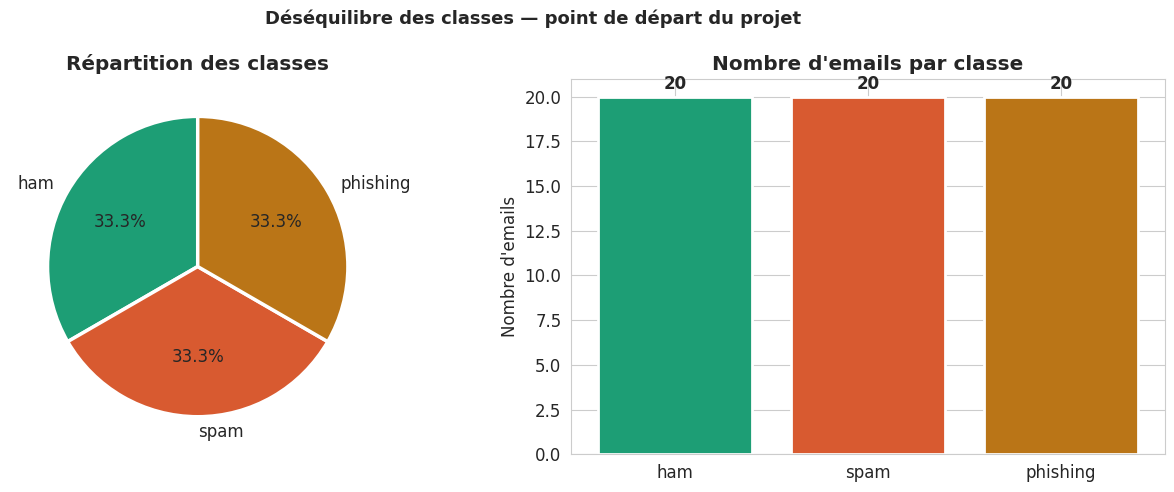

Ratio de déséquilibre (max/min) : 1.0x


In [27]:
# ---- 3.1 Distribution des classes ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

class_counts = df['label'].value_counts()
pie_colors   = [CLASS_COLORS.get(l, '#888') for l in class_counts.index]

# Camembert
axes[0].pie(
    class_counts.values,
    labels=class_counts.index,
    colors=pie_colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2.5}
)
axes[0].set_title('Répartition des classes', fontweight='bold')

# Barplot
bars = axes[1].bar(class_counts.index, class_counts.values,
                   color=pie_colors, edgecolor='white', linewidth=2)
axes[1].set_title('Nombre d\'emails par classe', fontweight='bold')
axes[1].set_ylabel('Nombre d\'emails')
for bar, val in zip(bars, class_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(class_counts)*0.01,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Déséquilibre des classes — point de départ du projet', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Calcul du ratio de déséquilibre
if len(class_counts) >= 2:
    ratio = class_counts.max() / class_counts.min()
    print(f'Ratio de déséquilibre (max/min) : {ratio:.1f}x')
    if ratio > 5:
        print('→ Déséquilibre significatif. SMOTE et class_weight seront nécessaires (NB 02).')

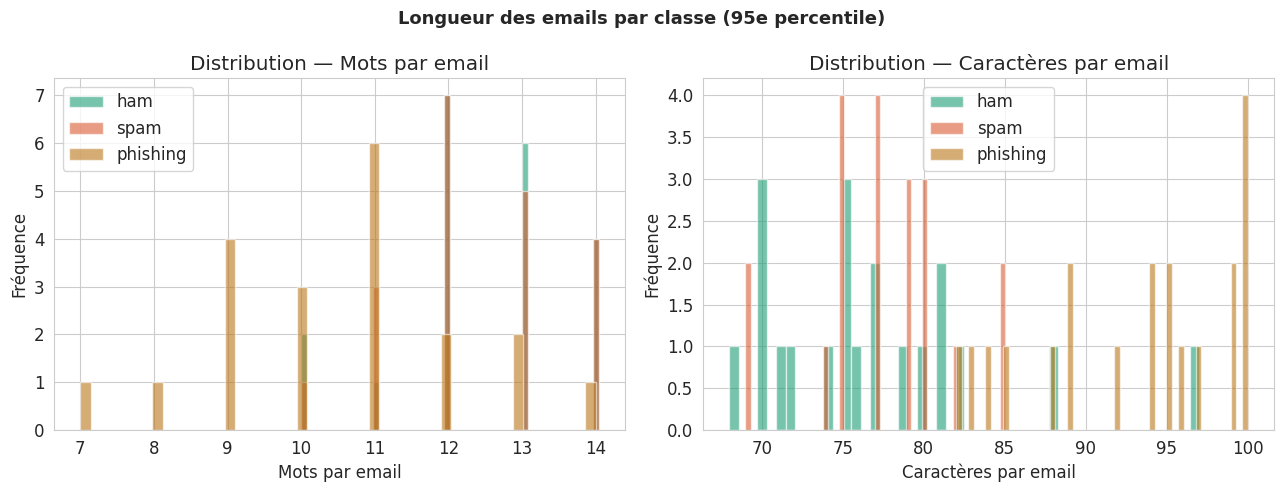

In [28]:
# ---- 3.2 Longueur des emails par classe ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, xlabel in zip(
    axes,
    ['word_count', 'char_count'],
    ['Mots par email', 'Caractères par email']
):
    for label in df['label'].unique():
        vals = df[df['label'] == label][col].clip(upper=df[col].quantile(0.95))
        ax.hist(vals, bins=50, alpha=0.6, label=label, color=CLASS_COLORS.get(label, 'gray'))
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Fréquence')
    ax.set_title(f'Distribution — {xlabel}')
    ax.legend()

plt.suptitle('Longueur des emails par classe (95e percentile)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data/01_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

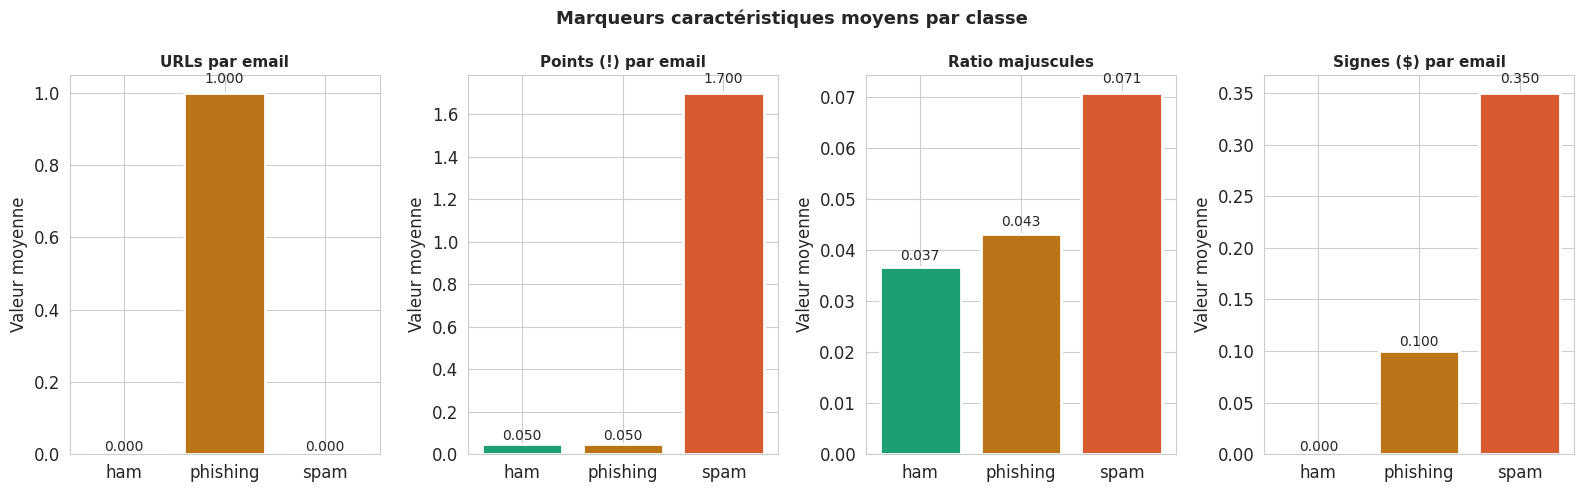

Interprétation attendue :
  - Phishing : forte densité d'URLs, peu de !
  - Spam     : beaucoup de !, $, majuscules
  - Ham      : peu de marqueurs suspects


In [29]:
# ---- 3.3 Marqueurs discriminants par classe ----
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

features_to_plot = ['url_count', 'exclamation', 'uppercase_ratio', 'dollar_count']
titles = ['URLs par email', 'Points (!) par email', 'Ratio majuscules', 'Signes ($) par email']

for ax, feat, title in zip(axes, features_to_plot, titles):
    grouped = df.groupby('label')[feat].mean()
    bar_colors = [CLASS_COLORS.get(l, 'gray') for l in grouped.index]
    bars = ax.bar(grouped.index, grouped.values, color=bar_colors, edgecolor='white', linewidth=2)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel('Valeur moyenne')
    for bar, val in zip(bars, grouped.values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() * 1.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Marqueurs caractéristiques moyens par classe', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data/01_discriminant_features.png', dpi=150, bbox_inches='tight')
plt.show()

print('Interprétation attendue :')
print('  - Phishing : forte densité d\'URLs, peu de !')
print('  - Spam     : beaucoup de !, $, majuscules')
print('  - Ham      : peu de marqueurs suspects')

/tmp/ipykernel_4523/570882413.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


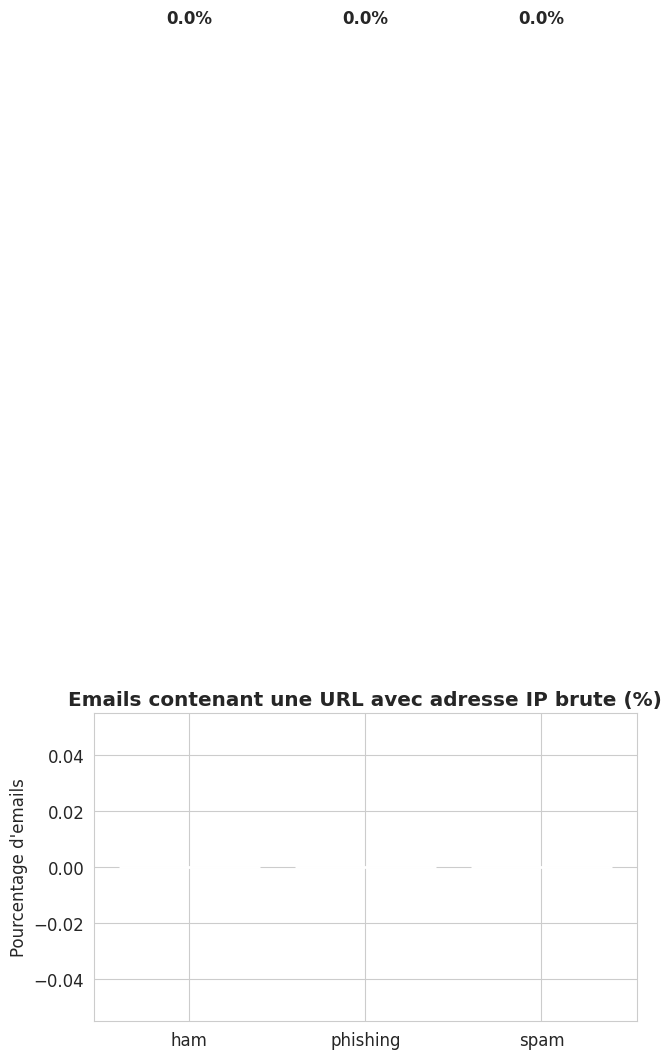

Les URLs de type http://192.168.x.x sont un indicateur fort de phishing.


In [30]:
# ---- 3.4 Présence d'IP dans les URLs (marqueur fort de phishing) ----
ip_url_by_class = df.groupby('label')['has_ip_url'].mean() * 100

plt.figure(figsize=(7, 4))
bars = plt.bar(
    ip_url_by_class.index,
    ip_url_by_class.values,
    color=[CLASS_COLORS.get(l, 'gray') for l in ip_url_by_class.index],
    edgecolor='white', linewidth=2
)
for bar, val in zip(bars, ip_url_by_class.values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
plt.title('Emails contenant une URL avec adresse IP brute (%)', fontweight='bold')
plt.ylabel('Pourcentage d\'emails')
plt.tight_layout()
plt.savefig('data/01_ip_url_presence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Les URLs de type http://192.168.x.x sont un indicateur fort de phishing.')

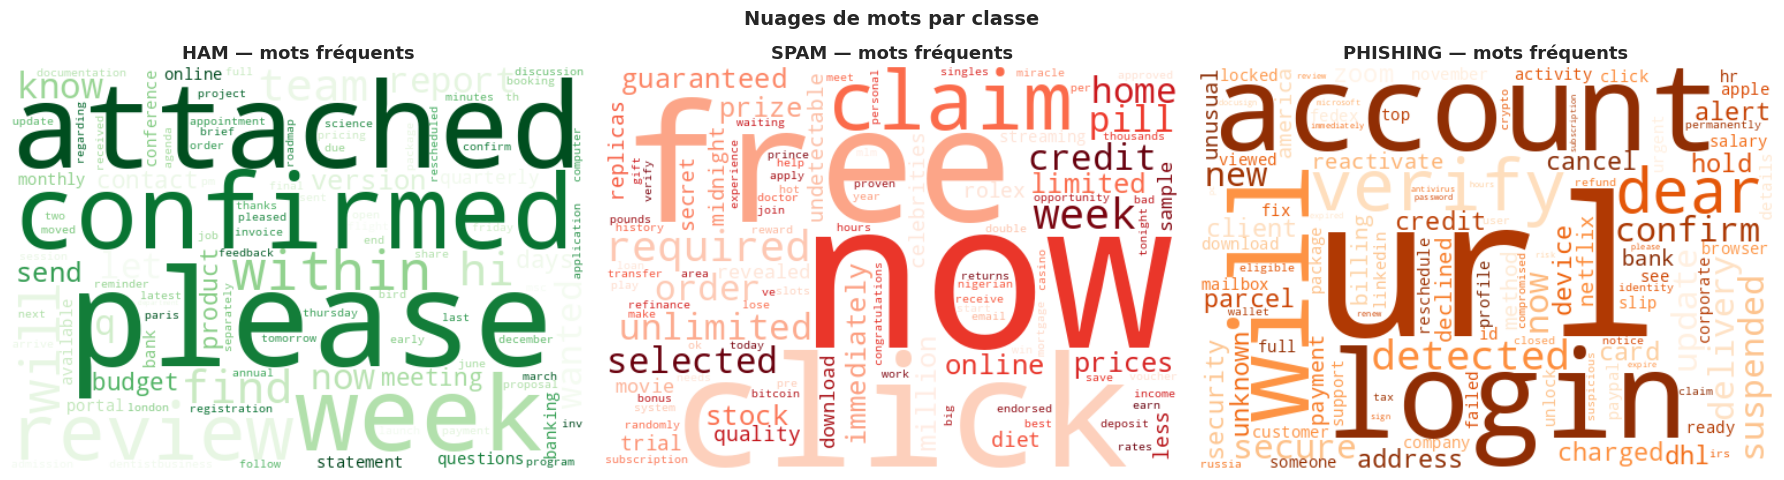

In [31]:
# ---- 3.5 WordClouds par classe ----
try:
    labels = df['label'].unique()
    fig, axes = plt.subplots(1, len(labels), figsize=(6*len(labels), 5))
    if len(labels) == 1:
        axes = [axes]

    for ax, label in zip(axes, labels):
        corpus = ' '.join(df[df['label'] == label]['text'].values)
        corpus = re.sub(r'https?://\S+', ' URL ', corpus)   # Remplace les URLs
        corpus = re.sub(r'[^a-zA-Z\s]', ' ', corpus).lower()

        cmap = {'ham': 'Greens', 'spam': 'Reds', 'phishing': 'Oranges'}.get(label, 'Blues')
        wc = WordCloud(
            width=500, height=350, background_color='white',
            colormap=cmap, max_words=100, collocations=False
        ).generate(corpus)

        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(f'{label.upper()} — mots fréquents', fontweight='bold', fontsize=13)

    plt.suptitle('Nuages de mots par classe', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('data/01_wordclouds.png', dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f'WordCloud non disponible : {e}')

## 4. Statistiques descriptives complètes

In [32]:
num_cols = ['word_count', 'char_count', 'url_count', 'exclamation', 'dollar_count', 'uppercase_ratio']
stats = df.groupby('label')[num_cols].agg(['mean', 'median', 'std']).round(3)

print('Statistiques par classe')
print('=' * 80)
print(stats.to_string())

print(f'\nRésumé global')
print(f'  Total emails          : {len(df):,}')
print(f'  Classes               : {sorted(df["label"].unique())}')
print(f'  Sources               : {sorted(df["source"].unique())}')
print(f'  Emails avec HTML      : {df["has_html"].sum():,} ({df["has_html"].mean()*100:.1f}%)')
print(f'  Emails avec URLs      : {(df["url_count"]>0).sum():,} ({(df["url_count"]>0).mean()*100:.1f}%)')
print(f'  Emails avec IP URL    : {df["has_ip_url"].sum():,} ({df["has_ip_url"].mean()*100:.1f}%)')

Statistiques par classe
         word_count               char_count               url_count             exclamation               dollar_count               uppercase_ratio              
               mean median    std       mean median    std      mean median  std        mean median    std         mean median    std            mean median    std
label                                                                                                                                                              
ham           12.65   12.5  1.694      76.90   75.5  6.889       0.0    0.0  0.0        0.05    0.0  0.224         0.00    0.0  0.000           0.037  0.034  0.018
phishing      10.55   11.0  1.761      93.60   94.5  7.236       1.0    1.0  0.0        0.05    0.0  0.224         0.10    0.0  0.308           0.043  0.040  0.018
spam          12.55   12.0  1.432      77.45   77.0  4.236       0.0    0.0  0.0        1.70    2.0  0.801         0.35    0.0  0.489           0.071  0.064

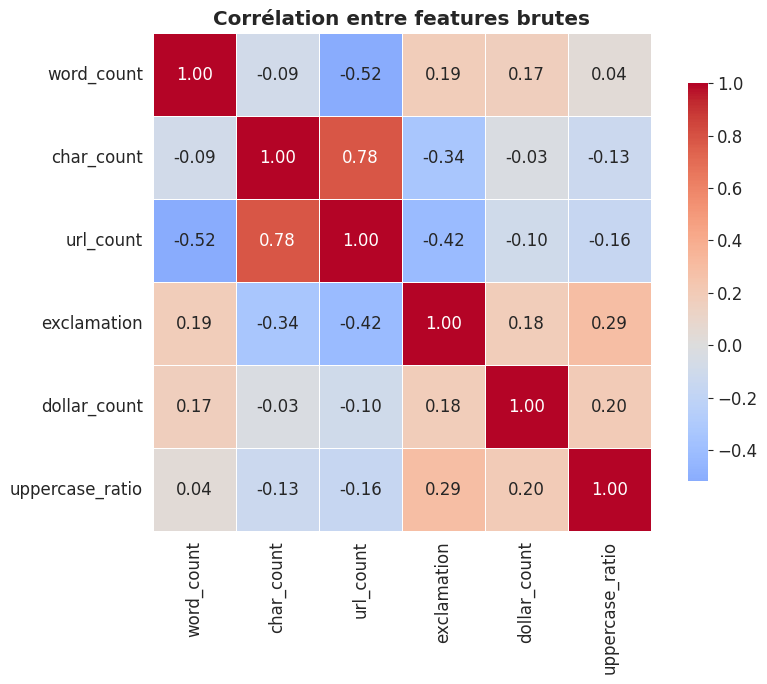

In [33]:
# Matrice de corrélation des features numériques
corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Corrélation entre features brutes', fontweight='bold')
plt.tight_layout()
plt.savefig('data/01_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Exemples annotés (inspection manuelle)

In [34]:
for label in sorted(df['label'].unique()):
    print(f'\n{"="*65}')
    print(f'CLASSE : {label.upper()}')
    print('='*65)
    samples = df[df['label'] == label].sample(min(2, len(df[df['label']==label])), random_state=1)
    for i, (_, row) in enumerate(samples.iterrows(), 1):
        preview = row['text'][:400].replace('\n', ' ')
        print(f'\n  Exemple {i} (source: {row["source"]}) :')
        print(f'  {preview}' + ('...' if len(row['text']) > 400 else ''))


CLASSE : HAM

  Exemple 1 (source: synthetic) :
  Hi, I wanted to share the latest version of the project documentation.

  Exemple 2 (source: synthetic) :
  The IT department will perform scheduled maintenance on Saturday from 2 to 4 AM.

CLASSE : PHISHING

  Exemple 1 (source: synthetic) :
  Your Zoom account will be suspended. Reactivate: http://zoom-account-reactivate.info

  Exemple 2 (source: synthetic) :
  Your crypto wallet has been compromised. Verify immediately: http://coinbase-wallet-secure.net

CLASSE : SPAM

  Exemple 1 (source: synthetic) :
  Congratulations! You've been randomly selected to receive a $1000 gift voucher!

  Exemple 2 (source: synthetic) :
  You have won a FREE iPhone 15! Click here to claim your prize before it expires!


## 6. Export du dataset brut

In [35]:
# Colonnes exportées vers le Notebook 02
cols_to_export = ['text', 'label', 'source',
                  'word_count', 'char_count', 'url_count',
                  'exclamation', 'uppercase_ratio', 'has_html',
                  'has_ip_url', 'dollar_count']

output_path = DATA_DIR / 'emails_raw.csv'
df[cols_to_export].to_csv(output_path, index=False, encoding='utf-8')

# Vérification
df_check = pd.read_csv(output_path)
assert len(df_check) == len(df), 'Erreur : fichier incomplet !'

print(f'Dataset exporté : {output_path}')
print(f'  Taille fichier : {output_path.stat().st_size / 1024:.0f} KB')
print(f'  Lignes         : {len(df_check):,}')
print(f'  Colonnes       : {list(df_check.columns)}')
print()
print('Prêt pour le Notebook 02 — Prétraitement & Feature Engineering.')

Dataset exporté : data/emails_raw.csv
  Taille fichier : 8 KB
  Lignes         : 60
  Colonnes       : ['text', 'label', 'source', 'word_count', 'char_count', 'url_count', 'exclamation', 'uppercase_ratio', 'has_html', 'has_ip_url', 'dollar_count']

Prêt pour le Notebook 02 — Prétraitement & Feature Engineering.


## 7. Résumé & observations clés

### Ce que ce notebook a produit
- `data/emails_raw.csv` — dataset fusionné prêt pour NB 02
- 5 graphiques d'exploration dans `data/01_*.png`

### Observations importantes

| Observation | Impact sur la suite |
|-------------|---------------------|
| Déséquilibre classes (phishing << spam/ham) | SMOTE + class_weight en NB 02 |
| URLs brutes (IP) = fort indicateur phishing | Feature prioritaire en NB 02 |
| Majuscules et `!` discriminent le spam | Features textuelles simples efficaces |
| Ham : texte long, peu de marqueurs | Bonne séparabilité attendue |

### Risques identifiés (cahier de charges §1)
- **Déséquilibre** (§1.3) → traité en NB 02
- **Données synthétiques** si corpus réels absents → enrichir dès que possible
- **Concept drift** (§1.2) → mécanisme de réentraînement prévu en NB 06

### Prochain notebook
**NB 02 — Prétraitement & Feature Engineering** :
nettoyage du texte, TF-IDF, extraction d'URLs structurées, SMOTE, séparation train/val/test.